<a href="https://colab.research.google.com/github/Deyonrose/labexercises/blob/LLM/DEYON_2348513_LLM_CIA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LLM CIA 2**

QUESTION 1 - Implement Positional Encoding

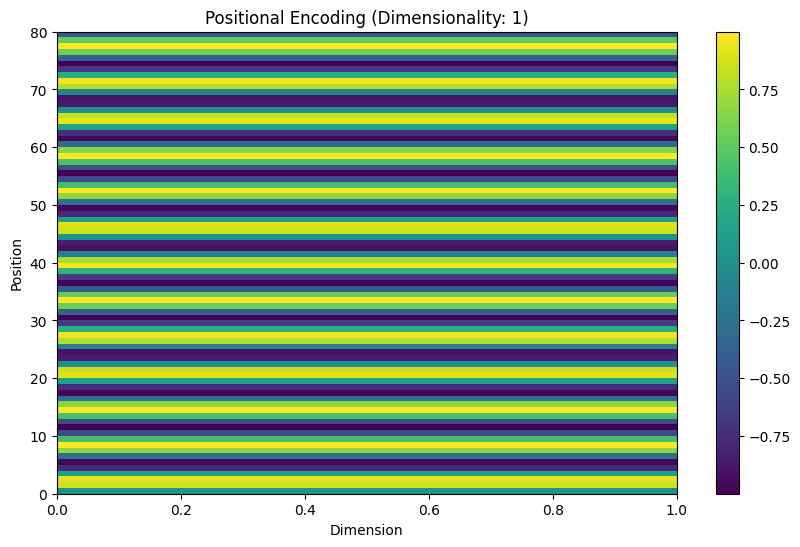

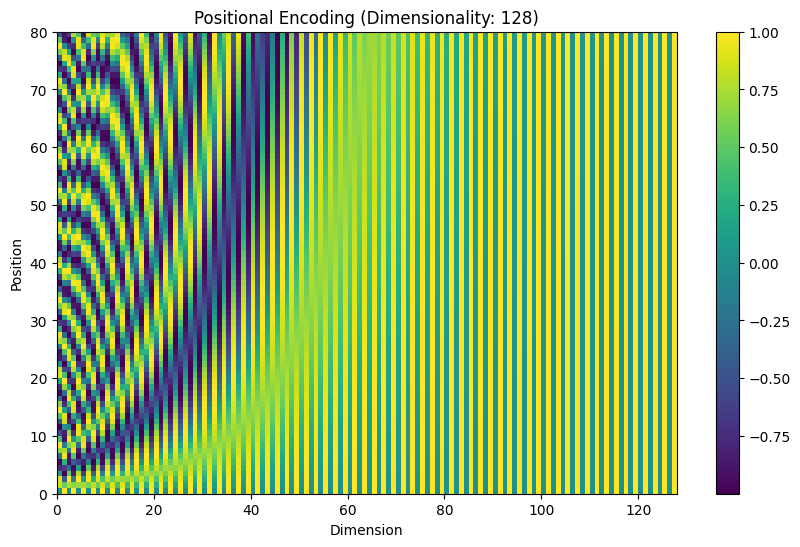

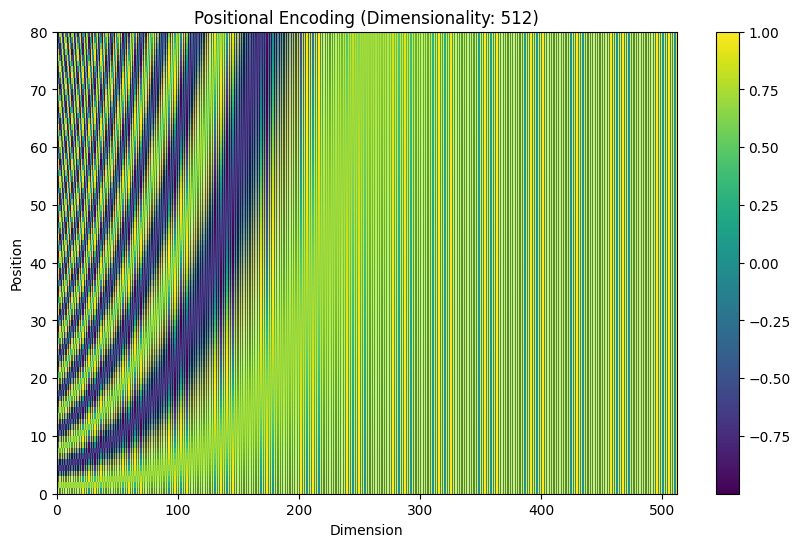

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#defining a function positional encoding and passing the parameters
def positional_encoding(max_position, d_model):
    pos = np.arange(max_position)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    # applying sin to even indices in the array; 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # applying cos to odd indices in the array; 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return angle_rads

def plot_positional_encoding(positional_encoding, d_model):
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(positional_encoding, cmap='viridis')
    plt.ylabel('Position')
    plt.xlabel('Dimension')
    plt.colorbar()
    plt.title(f'Positional Encoding (Dimensionality: {d_model})')
    plt.show()

# Defining the parameters like position and dimention
max_position = 80
d_models = [1, 128, 512]

# ploting the positional encoding with different dimentions 1,128 and 512
for d_model in d_models:
    pos_encoding = positional_encoding(max_position, d_model)
    plot_positional_encoding(pos_encoding, d_model)

QUESTION 2 - Implement Natural Language Generation

Importing neccessary libraries for poem generation


In [ ]:
!pip install langchain
!pip install langchain-groq

From langchain we are importing neccessary packages

In [ ]:
from langchain.prompts import PromptTemplate #class which is used to define and manage prompts for language models.
from langchain_core.output_parsers import StrOutputParser #return string output
from langchain_groq import ChatGroq # LLM model chatbot from langchain library that allows to query a vector database using natural language.
import os # interacting with the operating system

In [ ]:
# Retrieving the API Key
api_key = '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'
# Printing the API key
print(api_key)

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


In [ ]:
# In this we are Creating a ChatGroq instance with the provided API key and model gemma2-9b-it.
# It will initializes LLM ChatGroq model from langchain it helps to interact with  a vector database using natural language queries.
model = ChatGroq(api_key=api_key, model_name='gemma2-9b-it')


In [ ]:
parser = StrOutputParser()# it is for parsing the output of the language model into a string.
# Chain is a sequence of components that process input and generate output.
chain = model | parser # This chain allows to send a prompt to the language model and receive a parsed string as output.
chain.invoke(' poem about my mother')# helps to invoke the chain with the given prompt

'Please tell me a little about your mother so I can write a poem just for her! \n\nFor example, you could tell me about:\n\n* **Her personality:** Is she kind, funny, strong, adventurous?\n* **Her hobbies or passions:** Does she love to garden, cook, read, travel?\n* **Special memories you share:** Is there a particular moment or tradition that stands out?\n* **What you admire most about her:**  Her strength, her wisdom, her love?\n\nThe more details you give me, the more personal and heartfelt the poem will be. 💕 \n'

POEM CREATION About **MY MOTHER**

In [ ]:
# This template is to generate poem
template = (
    """
    you're  a poem creation expert
answer : {answer}
"""
)

In [ ]:
# we are creating a PromptTemplate object from the template string.
# PromptTemplate is a class in LangChain that provides a structured way to define and manage prompts for language models.
prompt = PromptTemplate.from_template(template=template)

In [ ]:
# This chain first formats the prompt using the PromptTemplate then sends the formatted prompt to the language model
# Then it parses the output of the language model into a string.
chain =  prompt | model | parser

In [ ]:
#giving details about the content of the poem
answer = """
  poem about my mother she is very kind,my best friend,teacher for me,my backbone,my strength ,my secret keeper,my life,like a bow for the sinking ship,the sinking ship refers to me.
"""

In [ ]:
# printing the result
result = chain.invoke({'answer':answer})
print(result)

My mother, a heart of purest gold,
Kindness in her touch, a story told.
More than just a parent, a friend so true,
Sharing laughter, wiping tears anew.

A teacher wise, with gentle hand,
Guiding me through life's shifting sand.
She shows me right from wrong, she shows me how,
To face the world with strength, and speak my vow.

My backbone strong, when I feel weak,
Her love a shelter, where dreams can peak.
A pillar of support, through sunshine bright,
And stormy nights, she shines her guiding light.

My secrets safe, within her keep,
A bond unbreakable, promises deep.
She listens patiently, with understanding gaze,
Turning worries into sunshine's rays.

My life, she is, the very core,
A love that blooms forevermore.
Like a bow for the sinking ship, she stands,
A beacon of hope, in troubled lands.

Her love, a lifeline, strong and bold,
My mother's story, forever told. 




